In [1]:
%config InlineBackend.figure_formats = ['retina']
from quimb.schematic import Drawing
import matplotlib as mpl  # noqa
import matplotlib.pyplot as plt  # noqa

from utils_draw import (
    get_presets,
    get_color,
    draw_cluster,
    draw_cluster_3d,
    color_tensor,
    color_tensor_su,
    color_gauge,
    color_su_gauge,
    color_op,
    color_su_gauge_sqrt,
    traced_bond,
)

mpl.rcParams["font.family"] = "Inter"
plt.rcParams["mathtext.fontset"] = "cm"

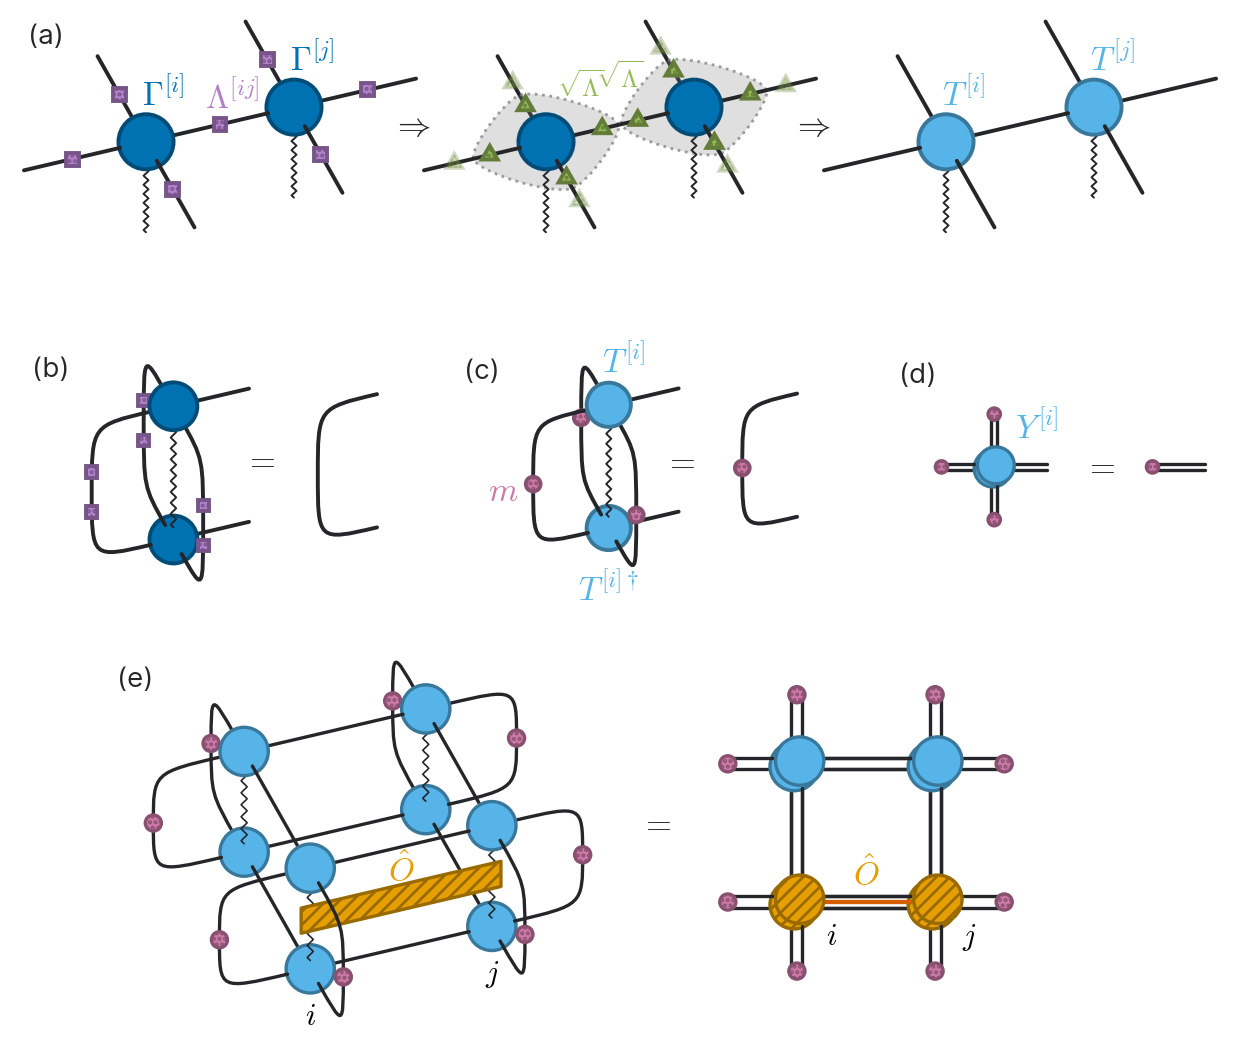

In [2]:
fig = plt.figure(figsize=(6, 6))

ax = fig.add_axes([0.0, 1 - 1 / 3, 1 / 3, 1 / 3])
presets = get_presets(r_scale=0.7, lw_scale=0.7)
d = Drawing(presets=presets, ax=ax, adjust_lims=True)

d.circle((0, 0, 0), preset="tensor_su")
d.circle((1, 0, 0), preset="tensor_su")
# bond between
d.line((0, 0, 0), (1, 0, 0), preset="bond")
d.square((0.5, 0, 0), preset="gauge_su")
# neighbors left
d.line((0, 0, 0), (-1, 0, 0), preset="bond")
d.square((-0.5, 0, 0), preset="gauge_su")
d.line((0, 0, 0), (0, 1, 0), preset="bond", shorten=(0.2, 0.1))
d.square((0, -0.5, 0), preset="gauge_su")
d.square((0, +0.5, 0), preset="gauge_su")
d.line((0, 0, 0), (0, -1, 0), preset="bond", shorten=(0.2, 0.1))
# neighbors right
d.line((1, 0, 0), (2, 0, 0), preset="bond")
d.square((1.5, 0, 0), preset="gauge_su")
d.line((1, 0, 0), (1, 1, 0), preset="bond", shorten=(0.2, 0.1))
d.square((1, 0.5, 0), preset="gauge_su")
d.line((1, 0, 0), (1, -1, 0), preset="bond", shorten=(0.2, 0.1))
d.square((1, -0.5, 0), preset="gauge_su")
d.zigzag((0, 0, 0), (0, 0, -3 / 4), preset="phys", shorten=0)
d.zigzag((1, 0, 0), (1, 0, -3 / 4), preset="phys", shorten=0)
d.text(
    (-0.03, 0, 0.4),
    r"$\Gamma^{[i]}$",
    ha="left",
    color=color_tensor_su,
    fontsize=12,
)
d.text(
    (1 - 0.03, 0, 0.4),
    r"$\Gamma^{[j]}$",
    ha="left",
    color=color_tensor_su,
    fontsize=12,
)
d.text(
    (0.5 - 0.1, 0, 0.25),
    r"$\Lambda^{[ij]}$",
    ha="left",
    color=color_su_gauge,
    fontsize=12,
)
d.label_ax(0.02, 0.98, "(a)", ha="left", va="top")
d.label_ax(0.98, 0.5, r"$\Rightarrow$", fontsize=12)

ax = fig.add_axes([1 / 3, 1 - 1 / 3, 1 / 3, 1 / 3])
d = Drawing(presets=presets, ax=ax, adjust_lims=True)
dg = 0.12
d.circle((0, 0, 0), preset="tensor_su")
d.circle((1, 0, 0), preset="tensor_su")
# bond between
d.line((0, 0, 0), (1, 0, 0), preset="bond")
d.marker((0.5 - dg, 0, 0), preset="gauge_su_sqrt")
d.marker((0.5 + dg, 0, 0), preset="gauge_su_sqrt")
d.text(
    (0.5 - dg - 0.15, 0, 0.4),
    r"$\sqrt{\Lambda}$",
    fontsize=9,
    color=color_su_gauge_sqrt,
)
d.text(
    (0.5 + dg - 0.12, 0, 0.4),
    r"$\sqrt{\Lambda}$",
    fontsize=9,
    color=color_su_gauge_sqrt,
)
# neighbors left
d.line((0, 0, 0), (-1, 0, 0), preset="bond")
d.marker((-0.5 - dg, 0, 0), preset="gauge_su_sqrt", alpha=0.3)
d.marker((-0.5 + dg, 0, 0), preset="gauge_su_sqrt")
d.line((0, 0, 0), (0, 1, 0), preset="bond", shorten=(0.2, 0.1))
d.marker((0, -0.5 - dg, 0), preset="gauge_su_sqrt", alpha=0.3)
d.marker((0, -0.5 + dg, 0), preset="gauge_su_sqrt")
d.marker((0, +0.5 - dg, 0), preset="gauge_su_sqrt")
d.marker((0, +0.5 + dg, 0), preset="gauge_su_sqrt", alpha=0.3)
d.line((0, 0, 0), (0, -1, 0), preset="bond", shorten=(0.2, 0.1))
# neighbors right
d.line((1, 0, 0), (2, 0, 0), preset="bond")
d.marker((1.5 - dg, 0, 0), preset="gauge_su_sqrt")
d.marker((1.5 + dg, 0, 0), preset="gauge_su_sqrt", alpha=0.3)
d.line((1, 0, 0), (1, 1, 0), preset="bond", shorten=(0.2, 0.1))
d.marker((1, 0.5 - dg, 0), preset="gauge_su_sqrt")
d.marker((1, 0.5 + dg, 0), preset="gauge_su_sqrt", alpha=0.3)
d.line((1, 0, 0), (1, -1, 0), preset="bond", shorten=(0.2, 0.1))
d.marker((1, -0.5 - dg, 0), preset="gauge_su_sqrt", alpha=0.3)
d.marker((1, -0.5 + dg, 0), preset="gauge_su_sqrt")
# physical bonds
d.zigzag((0, 0, 0), (0, 0, -3 / 4), preset="phys", shorten=0)
d.zigzag((1, 0, 0), (1, 0, -3 / 4), preset="phys", shorten=0)
dp = 0.49
d.patch([(0 + dp, 0, 0), (0, 0 + dp, 0), (0 - dp, 0, 0), (0, 0 - dp, 0)])
d.patch(
    [(1 + dp, 0, 0), (1, 0 + dp, 0), (1 - dp, 0, 0), (1, 0 - dp, 0)],
)
# d.label_fig(0.32, 0.17, "$=$", ha="center", va="center")
# d.label_ax(0.02, 0.98, "(b)", ha="left", va="top")
d.label_ax(0.98, 0.5, r"$\Rightarrow$", fontsize=12)

ax = fig.add_axes([2 / 3, 1 - 1 / 3, 1 / 3, 1 / 3])
d = Drawing(presets=presets, ax=ax, adjust_lims=True)
d.circle((0, 0, 0), preset="tensor")
d.circle((1, 0, 0), preset="tensor")
# bond between
d.line((0, 0, 0), (1, 0, 0), preset="bond")
# neighbors left
d.line((0, 0, 0), (-1, 0, 0), preset="bond")
d.line((0, 0, 0), (0, 1, 0), preset="bond", shorten=(0.2, 0.1))
d.line((0, 0, 0), (0, -1, 0), preset="bond", shorten=(0.2, 0.1))
# neighbors right
d.line((1, 0, 0), (2, 0, 0), preset="bond")
d.line((1, 0, 0), (1, 1, 0), preset="bond", shorten=(0.2, 0.1))
d.line((1, 0, 0), (1, -1, 0), preset="bond", shorten=(0.2, 0.1))
d.zigzag((0, 0, 0), (0, 0, -3 / 4), preset="phys", shorten=0)
d.zigzag((1, 0, 0), (1, 0, -3 / 4), preset="phys", shorten=0)
d.text(
    (-0.03, 0, 0.4),
    r"$T^{[i]}$",
    ha="left",
    color=get_color("blue"),
    fontsize=12,
)
d.text(
    (1 - 0.03, 0, 0.4),
    r"$T^{[j]}$",
    ha="left",
    color=get_color("blue"),
    fontsize=12,
)
# d.label_fig(2/3, 0.17, "$=$", ha="center", va="center")
# d.label_ax(0.02, 0.98, "(c)", ha="left", va="top")

midrow_dy = -0.03

ax = fig.add_axes([0.05, 0.45 + midrow_dy, 0.25, 0.25])
presets = get_presets(r_scale=0.55, lw_scale=0.7)
d = Drawing(presets=presets, ax=ax, adjust_lims=True)
q = 0.6
d.circle((0, 0, 1), preset="tensor_su")
d.circle((0, 0, 0), preset="tensor_su")
d.zigzag((0, 0, 0), (0, 0, 1), preset="phys")
traced_bond(d, (0, 0), (-1, 0), "su")
traced_bond(d, (0, 0), (0, +1), "su")
traced_bond(d, (0, 0), (0, -1), "su")
d.line((0, 0, 0), (q, 0, 0), preset="bond")
d.line((0, 0, 1), (q, 0, 1), preset="bond")
# d.marker((q / 2, 0, 0), preset="gauge_su")
# d.marker((q / 2, 0, 1), preset="gauge_su")
with d.translate_screen(1.3, 0.1):
    traced_bond(d, (0, 0), (-1, 0), "")
d.label_ax(0.6, 0.55, r"$=$", fontsize=12)
d.label_ax(-0.16, 0.98, "(b)", ha="left", va="top")

ax = fig.add_axes([0.40, 0.45 + midrow_dy, 0.25, 0.25])
presets = get_presets(r_scale=0.55, lw_scale=0.7)
d = Drawing(presets=presets, ax=ax, adjust_lims=True)
q = 0.6
d.circle((0, 0, 1), preset="tensor")
d.circle((0, 0, 0), preset="tensor")
d.zigzag((0, 0, 0), (0, 0, 1), preset="phys")
traced_bond(d, (0, 0), (-1, 0), "bp")
traced_bond(d, (0, 0), (0, +1), "bp")
traced_bond(d, (0, 0), (0, -1), "bp")
d.line((0, 0, 0), (q, 0, 0), preset="bond")
d.line((0, 0, 1), (q, 0, 1), preset="bond")
# d.marker((q / 2, 0, 0), preset="gauge_su")
# d.marker((q / 2, 0, 1), preset="gauge_su")
with d.translate_screen(1.3, 0.1):
    traced_bond(d, (0, 0), (-1, 0), "bp")
d.text((-0.7, 0, 0.5), r"$m$", color=color_gauge, fontsize=12)
d.text(
    (0.1, 0, 1.32), r"$T^{[i]}$", color=color_tensor, fontsize=12, ha="center"
)
d.text(
    (-0.0, 0, -0.5),
    r"$T^{[i]\dagger}$",
    color=color_tensor,
    fontsize=12,
    ha="center",
)
d.label_ax(0.6, 0.55, r"$=$", fontsize=12)
d.label_ax(-0.12, 0.98, "(c)", ha="left", va="top")

ax = fig.add_axes([0.76, 0.465 + midrow_dy, 0.23, 0.23])
presets = get_presets(r_scale=0.7, lw_scale=0.6)
d = Drawing(presets=presets, ax=ax, adjust_lims=True)
doffset = 0.03
draw_cluster([(0, 0)], d=d, leave_open=[(0.5, 0)], doffset=doffset)
d.text((1.0, 0.0), r"$=$", fontsize=12)
d.marker((1.5, 0), preset="gauge")
d.line((1.5, +doffset), (2.0, +doffset), preset="bond", shorten=0, zorder=-10)
d.line((1.5, -doffset), (2.0, -doffset), preset="bond", shorten=0, zorder=-10)
d.text(
    (0.2, 0.2),
    r"$Y^{[i]}$",
    ha="left",
    va="bottom",
    color=color_tensor,
    fontsize=12,
)
d.label_ax(-0.12, 1.36, "(d)", ha="left", va="top")

ax = fig.add_axes([0.1, 0.05, 0.38, 0.38])
presets = get_presets(r_scale=0.5, lw_scale=0.6)
d = Drawing(presets=presets, zscale=0.68, ax=ax, adjust_lims=True)
cluster = [(0, 0), (0, 1), (1, 0), (1, 1)]
targets = [(0, 0), (1, 0)]
draw_cluster_3d(
    cluster,
    d=d,
    targets=targets,
    drawtype="bp",
)
d.text((0.5, 0, 0.77), r"$\hat{O}$", color=color_op, fontsize=12)
d.text((0, 0, -0.47), r"$i$", color="k", fontsize=11, ha="center")
d.text((1, 0, -0.47), r"$j$", color="k", fontsize=11, ha="center")
d.label_ax(-0.05, 0.95, "(e)", ha="left", va="top")

ax = fig.add_axes([0.58, 0.12, 0.25, 0.25])
presets = get_presets(r_scale=0.7, lw_scale=0.6)
d = Drawing(presets=presets, ax=ax, adjust_lims=True)
draw_cluster(cluster, targets=targets, d=d)
# d.grid()
d.text((0.5, 0.2), r"$\hat{O}$", color=color_op, fontsize=12)
d.text((0 + 0.25, 0 - 0.25), r"$i$", color="k", fontsize=11)
d.text((1 + 0.25, 0 - 0.25), r"$j$", color="k", fontsize=11)
d.label_ax(-0.2, 0.53, r"$=$", fontsize=12)

In [3]:
fig.savefig("fig-0-message-passing.png", dpi=300, bbox_inches="tight")